####======================================================
### **Homework Assignment 5**
### Saurav Luthra, 55027009
### **ECE 648 - Machine Learning**

#### ====================================================
#### INTRODUCTION + OVERVIEW
#### ======================================================

This assignment focuses on analyzing vertebral column data from *Vertebral_column_3C.dat* to examine relationships between biomechanical features and the orthopaedic patients' classes (disk hernia, normal, spondilolysthesis). The dataset contains 310 data points (rows) and has 7 features (columns), including the label. For this assignment, the DH and SL labels were grouped into 1 label (ABNORMAL = 0) and NO was kept the same (NORMAL = 1). The aim is to create both a logistic regression classifier and a binary tree classifier. Both of these models' hyperparameters (C and max_depth) were optimzed over a speciified space using k-fold cross-validation with 10 folds.To achieve this the sklearn, numpy, pandas, seaborn, and matplotlib packages were used. The following steps were performed:

1. Values for 6 independent variables/features (unnamed) and the class, *label*, were loaded into a DataFrame. The data was split into a training set and testing set, with the DH and SL labels being grouped together. This leaves only 2 (binary) labels.

2. The 6-predictor logistic regression classifier was created and its confusion matrices, sensitivity, specificity, ROC curve, AUC, and prediction accuracies were calculated and displayed.

3. The 6-predictor binary tree classifier was created. Its confusion matrices, recall, precision, P-R curve, AUC, and prediction accuracies were calculated and displayed.


#### ====================================================
#### IMPORT PACKAGES
#### ======================================================

In [109]:
from distutils.version import LooseVersion

import matplotlib
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt

import numpy as np

import pandas as pd

import seaborn as sns

import sklearn
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

#### ====================================================
#### LOAD DATA INTO DATAFRAME
#### ======================================================

In [110]:
# create dataframe (df) from the input file
df = pd.read_csv('Vertebral_column_3C.dat', sep = '\s+', header = None)

# check df columns for missing values
df.isnull().sum().to_frame().transpose()

,0,1,2,3,4,5,6
0,0,0,0,0,0,0,0


In [111]:
# make X1 and X2 matrix
X = df.iloc[:, :6].rename(columns = {0: 'f0', 1: 'f1', 2: 'f2', 3: 'f3', 4: 'f4', 5: 'f5'})

In [112]:
X

,f0,f1,f2,f3,f4,f5
0,63.03,22.55,39.61,40.48,98.67,-0.25
1,39.06,10.06,25.02,29.00,114.41,4.56
2,68.83,22.22,50.09,46.61,105.99,-3.53
3,69.30,24.65,44.31,44.64,101.87,11.21
4,49.71,9.65,28.32,40.06,108.17,7.92
...,...,...,...,...,...,...
305,47.90,13.62,36.00,34.29,117.45,-4.25
306,53.94,20.72,29.22,33.22,114.37,-0.42
307,61.45,22.69,46.17,38.75,125.67,-2.71
308,45.25,8.69,41.58,36.56,118.55,0.21


In [113]:
# make y vector and map the labels to integers
# both DH and SL are abnormal (0) and NO is normal (1)

# 0 - disk hernia       - DH
# 0 - spondilolysthesis - SL
# 1 - normal            - NO

y = df.iloc[:, 6:].rename(columns={6: 'label'})

mapping = {'DH': 0, 'SL': 0, 'NO': 1}
y['label'] = y['label'].map(mapping)

y

,label
0,0
1,0
2,0
3,0
4,0
...,...
305,1
306,1
307,1
308,1


In [114]:
# get count of labels in y
y['label'].value_counts()

,count
label,
0,210
1,100


In [115]:
# split data into a training set (70%) and a testing set (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 1303, stratify = y)

In [116]:
# get counts of labels in y_train and y_test
print(y_train['label'].value_counts())
print(y_test['label'].value_counts())

label
0    147
1     70
Name: count, dtype: int64
label
0    63
1    30
Name: count, dtype: int64


In [117]:
# standardize features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [118]:
# transform the y vectors to be 1D arrays
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

In [119]:
# class label names
class_labels = ["ABNORMAL", "NORMAL"]

#### ====================================================
#### BUILD LOGISTIC REGRESSION CLASSIFIER
#### ======================================================

In [120]:
# number of folds for cross-validation
cv_k = 10

# space of regularization parameter, C
c_vals = [0.01, 0.10, 1.00, 10.00]

In [121]:
# build a logistic regression classifier to model y using X. choose the optimal C-value using cross validation
model1 = sklearn.linear_model.LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000)

# use cross validation to choose the right l2-regularization c-value
CV1 = sklearn.model_selection.GridSearchCV(model1, param_grid = {'C': c_vals}, cv = cv_k)
CV1.fit(X_train, y_train)

model1 = CV1.best_estimator_

y_pred1 = model1.predict(X_test)

In [122]:
# print best hyperparameters
print("Best Parameters:", CV1.best_params_)

# evaluate best model on test data
print("Test Accuracy:", model1.score(X_test, y_test))

Best Parameters: {'C': 1.0}
Test Accuracy: 0.8279569892473119


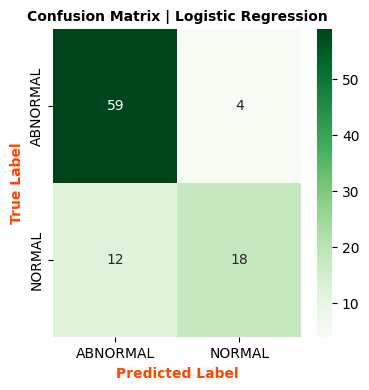

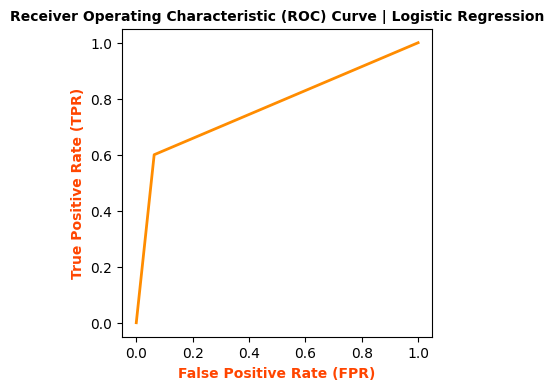


Area Under Curve (AUC): 0.768

Sensitivity: 0.600
Specificity: 0.937


In [124]:
# create and plot the confusion matrix
cm = confusion_matrix(y_test, y_pred1)
plt.figure(figsize = (4, 4))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Greens', xticklabels = class_labels, yticklabels = class_labels)

plt.title(f"Confusion Matrix | Logistic Regression", fontsize = 10, color = "black", fontweight = "bold")
plt.xlabel(f"Predicted Label", fontsize = 10, color = "orangered", fontweight = "bold")
plt.ylabel(f"True Label", fontsize = 10, color = "orangered", fontweight = "bold")
plt.show()

# plot the ROC curve
fpr, tpr, thresholds = sklearn.metrics.roc_curve(y_test, y_pred1)
plt.figure(figsize = (4, 4))
plt.plot(fpr, tpr, color = 'darkorange', lw = 2, label = 'ROC curve')
plt.title(f"Receiver Operating Characteristic (ROC) Curve | Logistic Regression", fontsize = 10, color = "black", fontweight = "bold")
plt.xlabel(f"False Positive Rate (FPR)", fontsize = 10, color = "orangered", fontweight = "bold")
plt.ylabel(f"True Positive Rate (TPR)", fontsize = 10, color = "orangered", fontweight = "bold")
plt.show()

# calculate AUC
auc = sklearn.metrics.roc_auc_score(y_test, y_pred1)
print(f"\nArea Under Curve (AUC): {auc:.3f}")

# calculate sensitivity and specificity
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f"\nSensitivity: {sensitivity:.3f}")
print(f"Specificity: {specificity:.3f}")

#### ====================================================
#### BUILD TREE CLASSIFIER
#### ======================================================



In [125]:
# number of folds for cross-validation
cv_k = 10

# values to try for tree's max depth
max_depth_vals = [3,4,5,6,7]

In [126]:
# create tree classifier and use 10-fold cv to optimize the max depth over max_depth_vals
model2 = DecisionTreeClassifier(criterion = "gini", random_state = 2105)

# use cross validation to choose the optimal max_depth value
CV2 = sklearn.model_selection.GridSearchCV(model2, param_grid = {'max_depth': max_depth_vals}, cv = cv_k)
CV2.fit(X_train, y_train)

model2 = CV2.best_estimator_
y_pred2 = model2.predict(X_test)

In [127]:
# print best hyperparameters
print("Best Parameters:", CV2.best_params_)

# evaluate best model on test data
print("Test Accuracy:", model2.score(X_test, y_test))

Best Parameters: {'max_depth': 3}
Test Accuracy: 0.7741935483870968


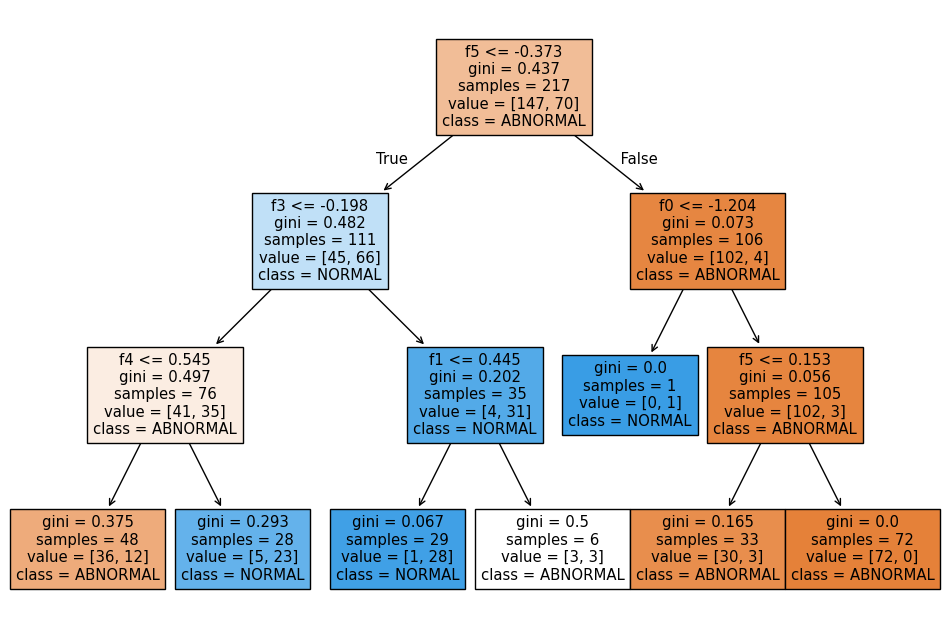

In [128]:
# plot tree
plt.figure(figsize = (12,8))
plot_tree(model2, feature_names = X.columns, class_names = class_labels, filled = True)
plt.show()

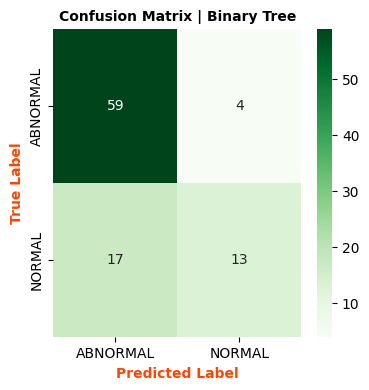

In [129]:
# create and plot confusion matrix
cm = confusion_matrix(y_test, y_pred2)
plt.figure(figsize = (4, 4))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Greens', xticklabels = class_labels, yticklabels = class_labels)

plt.title(f"Confusion Matrix | Binary Tree", fontsize = 10, color = "black", fontweight = "bold")
plt.xlabel(f"Predicted Label", fontsize = 10, color = "orangered", fontweight = "bold")
plt.ylabel(f"True Label", fontsize = 10, color = "orangered", fontweight = "bold")
plt.show()

In [130]:
# output tree classifier's prediction accuracy
print(classification_report(y_test, y_pred2, target_names = class_labels))
print(f"\n\nPrediction Accuracy: {accuracy_score(y_test, y_pred2):.3f}")

              precision    recall  f1-score   support

    ABNORMAL       0.78      0.94      0.85        63
      NORMAL       0.76      0.43      0.55        30

    accuracy                           0.77        93
   macro avg       0.77      0.68      0.70        93
weighted avg       0.77      0.77      0.75        93



Prediction Accuracy: 0.774


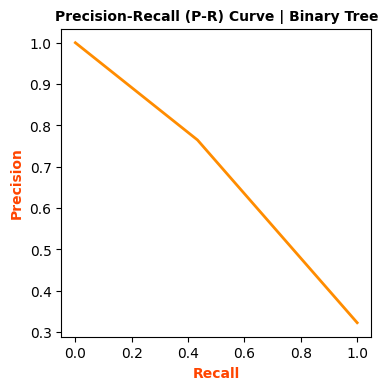


Area Under Curve (AUC): 0.685


In [131]:
# plot the precision-recall curve
precision, recall, thresholds = sklearn.metrics.precision_recall_curve(y_test, y_pred2)
plt.figure(figsize = (4, 4))
plt.plot(recall, precision, color = 'darkorange', lw = 2, label = 'P-R curve')

plt.title(f"Precision-Recall (P-R) Curve | Binary Tree", fontsize = 10, color = "black", fontweight = "bold")
plt.xlabel(f"Recall", fontsize = 10, color = "orangered", fontweight = "bold")
plt.ylabel(f"Precision", fontsize = 10, color = "orangered", fontweight = "bold")
plt.show()

# calculate AUC
auc = sklearn.metrics.roc_auc_score(y_test, y_pred2)
print(f"\nArea Under Curve (AUC): {auc:.3f}")

#### ====================================================
#### CONCLUSION
#### ======================================================

____________________________________________________________
**Logisitic Regression Classifier:**

Optimal C: 1.0

Test Accuracy: 0.828

Sensitivity: 0.600

Specificity: 0.937

AUC: 0.768

____________________________________________________________

**Binary Tree Classifier:**

Optimal Max Depth: 3

Prediction Accuracy: 0.774

Precision: 0.77

Recall: 0.77

AUC: 0.685


